# Подготовка данных


In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
df = pd.read_csv('train.csv')

In [108]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


In [109]:
df.shape

(11017, 36)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

Посмотрим корреляцию между числовыми признаками на данный момент.

In [111]:
# df.corr()['RiskScore'] - ошибка, потому что не обработаны категориальные признаки
df.select_dtypes(include=[float, int]).corr()['RiskScore']

,RiskScore
Age,-0.004648
AnnualIncome,-0.008460
CreditScore,0.002383
LoanAmount,0.011771
LoanDuration,-0.001880
NumberOfDependents,-0.023314
MonthlyDebtPayments,-0.001871
CreditCardUtilizationRate,0.005501
NumberOfOpenCreditLines,0.000730
NumberOfCreditInquiries,0.011055


Начинаем обрабатывать данные - убираем дубликаты и строки, состоящие только из NaN.

In [112]:
df = df.drop_duplicates()
df = df.dropna(how='all')
df.shape

(10000, 36)

In [113]:
df['RiskScore'].nunique()

9790

In [114]:
df['RiskScore'].describe()

,RiskScore
count,1.000000e+04
mean,-2.995269e+04
std,1.455787e+06
min,-9.999999e+06
25%,3.253485e+01
50%,4.409630e+01
75%,6.530486e+01
max,1.000000e+07


Тип данных float - отсюда так много уникальных значений.

Сделаем обычный boxplot для оценки выбросов.

<Axes: >

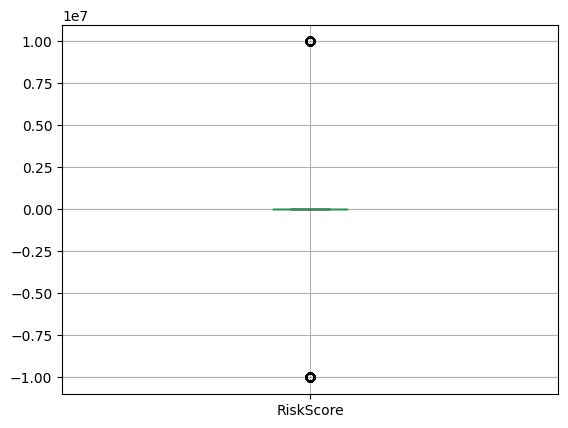

In [115]:
df.boxplot(column='RiskScore')

Логично предположить, что `RiskScore` - это вероятность, диапазон значений которой будет [0;100]. Отфильтруем столбик соответствующим образом и посмотрим, что получилось.

In [116]:
df = df[(df['RiskScore'] >= 0) & (df['RiskScore'] <= 100)]
df.shape

(9788, 36)

,RiskScore
count,9788.000000
mean,48.325333
std,17.233659
min,14.841417
25%,32.717486
50%,44.180868
75%,65.090711
max,97.597249


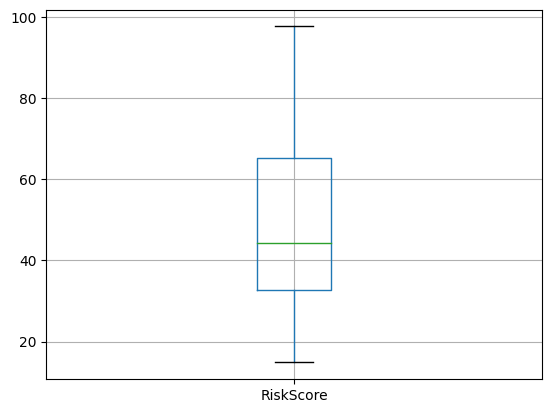

In [117]:
df.boxplot(column='RiskScore')
df['RiskScore'].describe()

Теперь все хорошо.

Поработаем с пропусками.

In [118]:
df.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,456
LoanAmount,456
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0
HomeOwnershipStatus,0
MonthlyDebtPayments,456


In [119]:
df[df.isna().any(axis=1)]

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
13,1997-02-26,27.0,15000.0,NaN,NaN,48.0,Married,5.0,Other,NaN,...,Employed,High School,5.0,NaN,NaN,0.343139,1097.352250,1.293082,0.0,67.304719
17,2009-06-11,43.0,43876.0,NaN,NaN,24.0,Married,3.0,Mortgage,NaN,...,Employed,Associate,20.0,NaN,NaN,0.109708,1694.354520,0.657586,0.0,48.636125
25,1983-12-01,56.0,15000.0,NaN,NaN,12.0,Married,1.0,Own,NaN,...,Employed,Bachelor,34.0,NaN,NaN,0.218868,822.309410,1.221048,0.0,70.406884
80,2019-07-05,44.0,136297.0,NaN,NaN,36.0,Single,0.0,Rent,NaN,...,Employed,High School,24.0,NaN,NaN,0.208675,1526.095455,0.245736,1.0,37.218934
95,2011-03-06,23.0,203619.0,NaN,NaN,24.0,Divorced,0.0,Mortgage,NaN,...,Employed,Associate,0.0,NaN,NaN,0.124805,815.846517,0.098233,1.0,38.026142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9917,1992-07-04,43.0,129456.0,NaN,NaN,12.0,Married,2.0,Mortgage,NaN,...,Employed,High School,25.0,NaN,NaN,0.129453,7308.696467,0.701492,0.0,40.397888
9937,1986-01-05,49.0,51227.0,NaN,NaN,24.0,Single,3.0,Rent,NaN,...,Employed,Associate,27.0,NaN,NaN,0.149436,1989.227880,0.648227,0.0,47.226112
9940,2006-10-28,43.0,15000.0,NaN,NaN,48.0,Divorced,0.0,Rent,NaN,...,Employed,High School,24.0,NaN,NaN,0.287904,347.056707,0.466445,1.0,53.624415
9972,2001-07-19,28.0,37520.0,NaN,NaN,36.0,Divorced,0.0,Mortgage,NaN,...,Employed,Bachelor,4.0,NaN,NaN,0.145322,1149.737731,0.527954,0.0,67.062142


In [120]:
df.head(10000)

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1995-06-09,27.0,15000.0,361.0,19505.0,36.0,Single,1.0,Other,622.0,...,Employed,High School,2.0,31346.0,0.334005,0.346203,878.142786,1.200114,0.0,76.185933
9996,2000-03-10,49.0,185082.0,573.0,7447.0,84.0,Married,0.0,Mortgage,946.0,...,Employed,High School,27.0,14016.0,0.255947,0.235055,181.438855,0.073099,1.0,41.213393
9997,2010-04-05,55.0,296728.0,850.0,44162.0,84.0,Divorced,2.0,Mortgage,479.0,...,Employed,High School,33.0,3624.0,0.154162,0.144973,839.774585,0.053333,1.0,43.699684
9998,2010-11-07,33.0,206277.0,NaN,NaN,24.0,Married,0.0,Mortgage,NaN,...,Self-Employed,High School,13.0,NaN,NaN,0.182289,3505.337200,0.220034,1.0,33.516126


Строки, включающие NaN - дропаем.

In [121]:
df = df.dropna()
df.shape

(9332, 36)

In [122]:
df[df.isna().any(axis=1)]

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore


In [123]:
df.head(10000)

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,1986-11-30,31.0,300000.0,850.0,14503.0,60.0,Married,2.0,Mortgage,185.0,...,Employed,Doctorate,10.0,6992.0,0.104503,0.113622,317.956385,0.020118,1.0,34.037970
9995,1995-06-09,27.0,15000.0,361.0,19505.0,36.0,Single,1.0,Other,622.0,...,Employed,High School,2.0,31346.0,0.334005,0.346203,878.142786,1.200114,0.0,76.185933
9996,2000-03-10,49.0,185082.0,573.0,7447.0,84.0,Married,0.0,Mortgage,946.0,...,Employed,High School,27.0,14016.0,0.255947,0.235055,181.438855,0.073099,1.0,41.213393
9997,2010-04-05,55.0,296728.0,850.0,44162.0,84.0,Divorced,2.0,Mortgage,479.0,...,Employed,High School,33.0,3624.0,0.154162,0.144973,839.774585,0.053333,1.0,43.699684


Отлично!
Теперь будем кодировать категориальные признаки.

In [124]:
df.select_dtypes(include=object)

,ApplicationDate,MaritalStatus,HomeOwnershipStatus,LoanPurpose,EmploymentStatus,EducationLevel
0,2010-06-26,Divorced,Rent,Education,Employed,Associate
1,1996-09-23,Widowed,Mortgage,Home,Employed,High School
2,2015-01-19,Married,Mortgage,Education,Employed,Bachelor
3,1981-05-12,Married,Other,Debt Consolidation,Employed,High School
4,1995-05-07,Single,Rent,Debt Consolidation,Employed,Bachelor
...,...,...,...,...,...,...
9994,1986-11-30,Married,Mortgage,Debt Consolidation,Employed,Doctorate
9995,1995-06-09,Single,Other,Education,Employed,High School
9996,2000-03-10,Married,Mortgage,Auto,Employed,High School
9997,2010-04-05,Divorced,Mortgage,Education,Employed,High School


Уникальных дат очень много, поэтому One-Hot Encoding не подходит.

In [125]:
df['ApplicationDate'].nunique()

9332

In [126]:
dff = df.copy()

In [127]:
dff['ApplicationDate'] = pd.to_datetime(dff['ApplicationDate'])  # Преобразуем строковые даты в тип datetime
dff['ApplicationDate'] = dff['ApplicationDate'].astype(int) / 10**9  # Преобразуем в секунды
dff['ApplicationDate']

,ApplicationDate
0,1.277510e+09
1,8.434368e+08
2,1.421626e+09
3,3.584736e+08
4,7.998048e+08
...,...
9994,5.336928e+08
9995,8.026560e+08
9996,9.526464e+08
9997,1.270426e+09


In [128]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9332 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             9332 non-null   float64
 1   Age                         9332 non-null   float64
 2   AnnualIncome                9332 non-null   float64
 3   CreditScore                 9332 non-null   float64
 4   LoanAmount                  9332 non-null   float64
 5   LoanDuration                9332 non-null   float64
 6   MaritalStatus               9332 non-null   object 
 7   NumberOfDependents          9332 non-null   float64
 8   HomeOwnershipStatus         9332 non-null   object 
 9   MonthlyDebtPayments         9332 non-null   float64
 10  CreditCardUtilizationRate   9332 non-null   float64
 11  NumberOfOpenCreditLines     9332 non-null   float64
 12  NumberOfCreditInquiries     9332 non-null   float64
 13  DebtToIncomeRatio           9332 non-n

Остальное закодируем через One-Hot Encoding.



In [129]:
dff = pd.get_dummies(data=dff, columns=dff.select_dtypes(include=object).columns, drop_first=True)

In [130]:
dff.dtypes

,0
ApplicationDate,float64
Age,float64
AnnualIncome,float64
CreditScore,float64
LoanAmount,float64
LoanDuration,float64
NumberOfDependents,float64
MonthlyDebtPayments,float64
CreditCardUtilizationRate,float64
NumberOfOpenCreditLines,float64


In [131]:
dff.shape

(9332, 47)

In [132]:
dff.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master
0,1.277510e+09,27.0,66829.0,549.0,17290.0,60.0,1.0,1095.0,0.151985,2.0,...,False,True,False,False,False,False,False,False,False,False
1,8.434368e+08,55.0,172147.0,850.0,16110.0,36.0,1.0,211.0,0.175693,3.0,...,False,False,True,False,False,False,False,False,True,False
2,1.421626e+09,51.0,300000.0,850.0,38436.0,36.0,0.0,546.0,0.444605,3.0,...,False,True,False,False,False,False,True,False,False,False
3,3.584736e+08,25.0,34683.0,847.0,19186.0,48.0,0.0,153.0,0.188452,7.0,...,True,False,False,False,False,False,False,False,True,False
4,7.998048e+08,55.0,300000.0,850.0,30437.0,48.0,2.0,562.0,0.273431,3.0,...,True,False,False,False,False,False,True,False,False,False


Посмотрим на итоговую корреляцию признаков с `RiskScore`.

In [133]:
dff.corr()['RiskScore']

,RiskScore
ApplicationDate,0.002558
Age,-0.042744
AnnualIncome,-0.757874
CreditScore,-0.785429
LoanAmount,0.079041
LoanDuration,0.025265
NumberOfDependents,0.008190
MonthlyDebtPayments,0.017922
CreditCardUtilizationRate,0.053080
NumberOfOpenCreditLines,-0.001151


Тут я попытался удалить признаки, которые имеют низкую корреляцию с `RiskScore`, но итоговый результат ожиданий не оправдал.

In [136]:
# correlations = df.corr()

# columns_to_keep = correlations.index[(correlations['RiskScore'] > 0.4) | (correlations['RiskScore'] < -0.4)].tolist()

# df = df[columns_to_keep]
# df.corr()['RiskScore']

Вывод: сильно коррелирующих с таргетом(`RiskScore`) признаков не много, однако эти признаки также могут коррелировать друг с другом, например, `AnnualInCome` и `CreditScore`, что важно учитывать при последующей обработке данных. Поэтому просто удаляя признаки с низкой корреляцией можно ухудшить итоговый результат.

Нужно визуализировать зависимость какой-нибудь части признаков от таргета. Для этого возьмем как раз `AnnualInCome`(Годовой доход) и `CreditScore` (Оценка кредитоспособности).

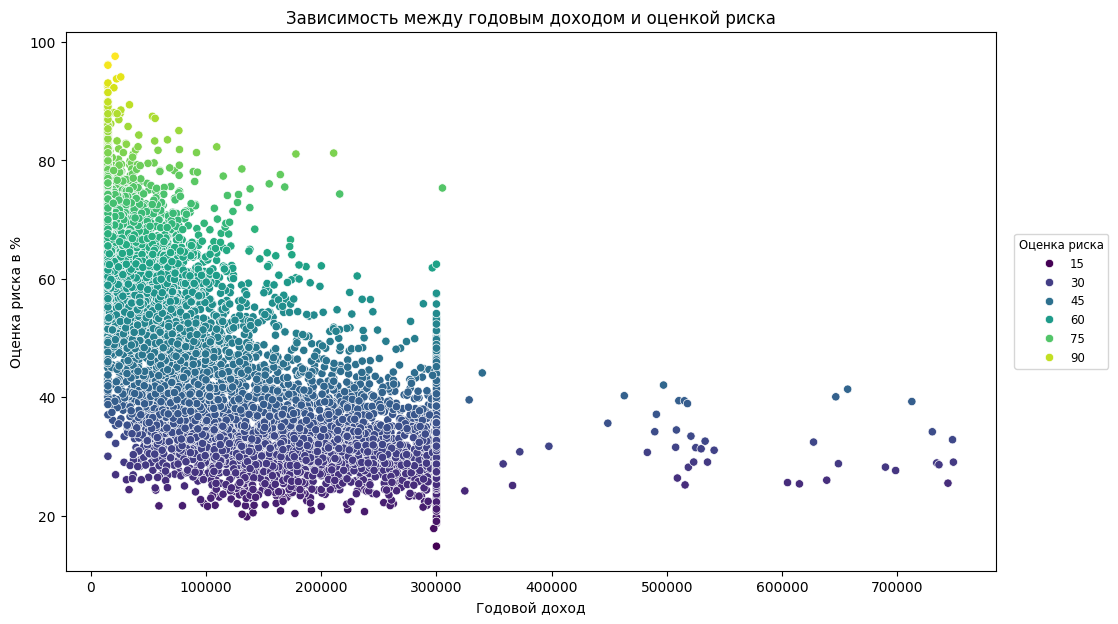

In [134]:
plt.figure(figsize=(12, 7))
sns.scatterplot(dff, x='AnnualIncome', y='RiskScore', hue='RiskScore', palette='viridis')
plt.title('Зависимость между годовым доходом и оценкой риска')
plt.xlabel('Годовой доход')
plt.ylabel('Оценка риска в %')
plt.legend(title='Оценка риска', loc='center left', fontsize='small', title_fontsize='small', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.show()

Можно заметить, что при более высоком доходе риск, как правило, ниже.

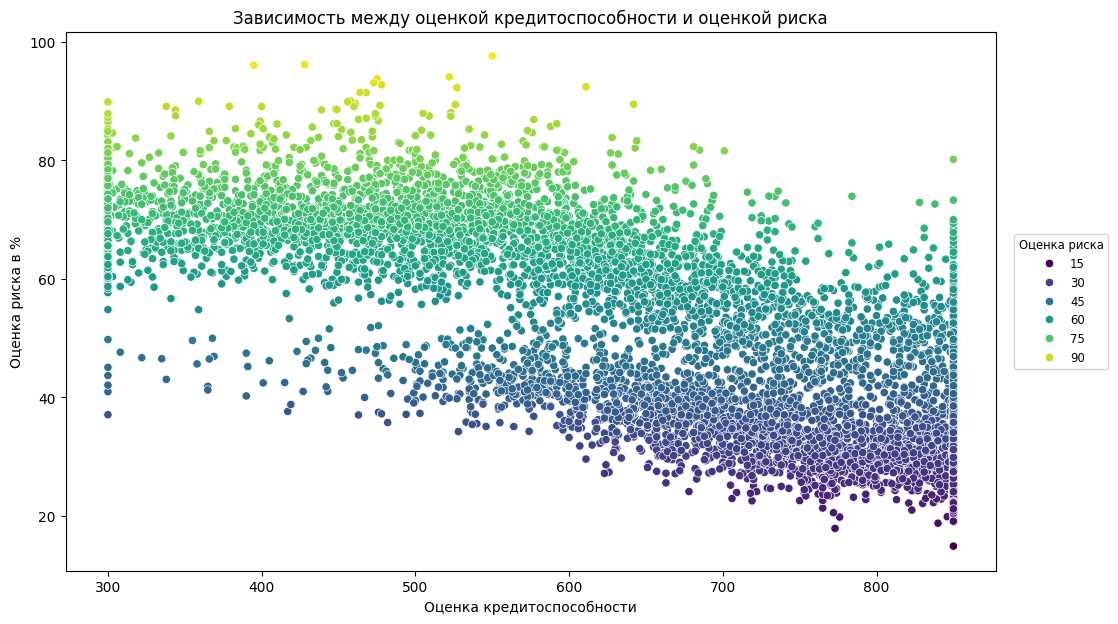

In [135]:
plt.figure(figsize=(12, 7))
sns.scatterplot(dff, x='CreditScore', y='RiskScore', hue='RiskScore', palette='viridis')
plt.title('Зависимость между оценкой кредитоспособности и оценкой риска')
plt.xlabel('Оценка кредитоспособности')
plt.ylabel('Оценка риска в %')
plt.legend(title='Оценка риска', loc='center left', fontsize='small', title_fontsize='small', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.show()

Можно заметить, что люди с более высоким кредитным рейтингом, как правило, имеют более низкий риск, что вполне закономерно.

# Поработаем с признаками.

Попробуем добавить новые/удалить старые/сгруппировать/наложить функции

In [33]:
dff.to_csv('dff.csv', index=False)

In [166]:
# dfx_base = dff.copy()
# dfx = dff.copy()

In [349]:
dfx = dfx_base.copy()

Дропаем то, что не окажет влияния на итоговый MSE.

In [350]:
dfx = dfx.drop(['ApplicationDate'],axis = 1)
dfx = dfx.drop(['Age'],axis = 1)
dfx = dfx.drop(['MonthlyLoanPayment'],axis = 1)
dfx = dfx.drop(['AnnualIncome'],axis = 1)
dfx = dfx.drop(['TotalAssets'],axis = 1)

Фиксим ассиметрию признаков.

In [351]:
from sklearn.preprocessing import PowerTransformer

dfx['ExpCreditScore'] = dfx['CreditScore']**3
dfx = dfx.drop(['CreditScore'],axis = 1)
# dfx['LogLoanAmount'] = np.log1p(dfx['LoanAmount'])
# dfx = dfx.drop(['LoanAmount'],axis = 1)
# dfx['MonthlyDebtPayments'] = np.log1p(dfx['MonthlyDebtPayments'])
dfx['SavingsAccountBalance'] = np.log1p(dfx['SavingsAccountBalance'])
dfx['CheckingAccountBalance'] = np.log1p(dfx['CheckingAccountBalance'])
dfx['TotalLiabilities'] = np.log1p(dfx['TotalLiabilities'])
dfx['TotalDebtToIncomeRatio'] = np.log1p(dfx['TotalDebtToIncomeRatio'])
dfx['NumberOfCreditInquiries'] = np.sqrt(dfx['NumberOfCreditInquiries'])
dfx['NumberOfDependents'] = np.sqrt(dfx['NumberOfDependents'])
dfx['LoanDuration'] = np.sqrt(dfx['LoanDuration'])
dfx['DebtToIncomeRatio'] = np.log1p(dfx['DebtToIncomeRatio'])
# dfx['UtilityBillsPaymentHistory'] = dfx['UtilityBillsPaymentHistory'] ** 3

pt_networth = PowerTransformer(method='yeo-johnson')
dfx['NetWorth'] = pt_networth.fit_transform(dfx[['NetWorth']])

In [283]:
skewness = dfx.skew()
print(skewness)

LoanAmount                        3.308166
LoanDuration                      0.035591
NumberOfDependents               -0.266551
MonthlyDebtPayments               3.523793
CreditCardUtilizationRate         0.579260
NumberOfOpenCreditLines           0.588543
NumberOfCreditInquiries          -0.069781
DebtToIncomeRatio                 0.706719
BankruptcyHistory                 4.027715
PreviousLoanDefaults              2.738771
PaymentHistory                    0.171503
LengthOfCreditHistory            -0.003466
SavingsAccountBalance             0.007279
CheckingAccountBalance           -0.040363
TotalLiabilities                 -0.001802
MonthlyIncome                     0.496115
UtilityBillsPaymentHistory       -0.754596
JobTenure                         0.452540
Experience                        0.324318
NetWorth                          0.052305
BaseInterestRate                  0.665040
InterestRate                      0.752079
TotalDebtToIncomeRatio            1.719701
LoanApprove

Построим матрицу корреляций для наглядности.

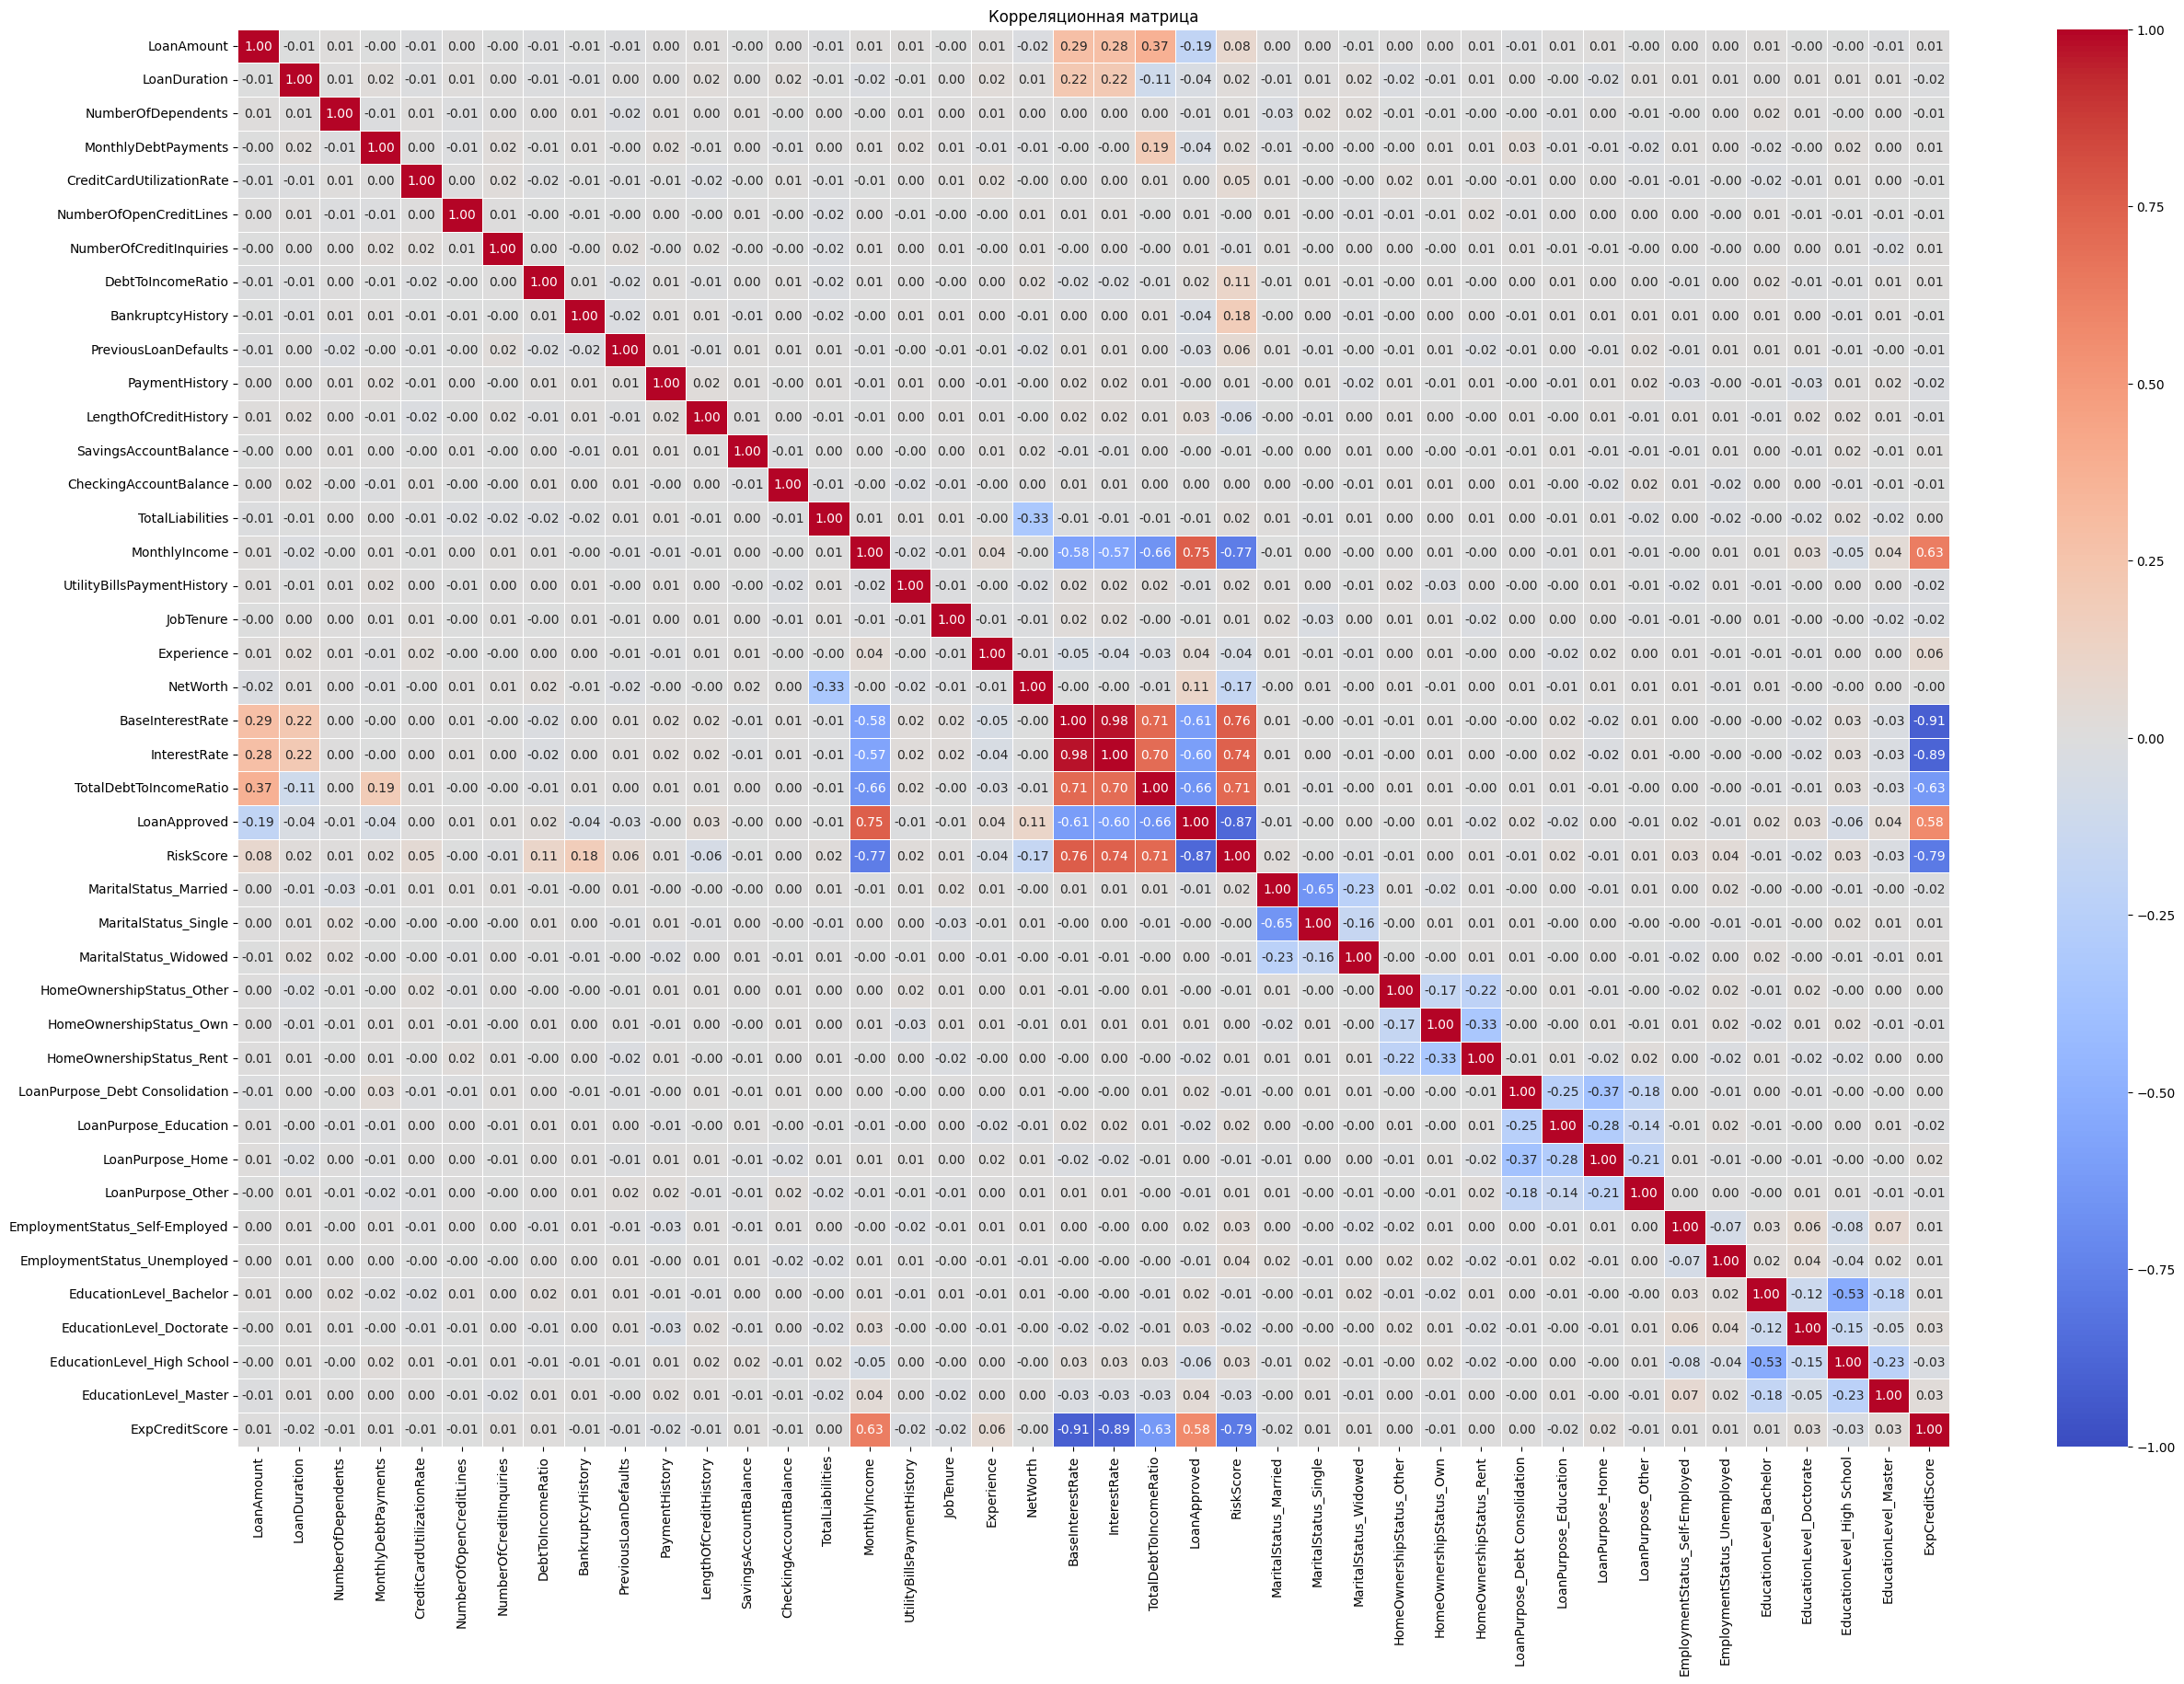

In [342]:
corr_matrix = dfx.corr()
plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5, fmt='.2f')
plt.title("Корреляционная матрица")
plt.show()

In [343]:
high_correlation_pairs = corr_matrix.unstack().reset_index()
high_correlation_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_correlation_pairs = high_correlation_pairs[high_correlation_pairs['Feature1'] != high_correlation_pairs['Feature2']]

high_correlation_pairs = high_correlation_pairs[high_correlation_pairs['Correlation'].abs() > 0.7]

high_correlation_pairs = high_correlation_pairs.sort_values(by='Correlation', ascending=False)

print(high_correlation_pairs)

                    Feature1                Feature2  Correlation
861         BaseInterestRate            InterestRate     0.975215
902             InterestRate        BaseInterestRate     0.975215
864         BaseInterestRate               RiskScore     0.759546
1028               RiskScore        BaseInterestRate     0.759546
653            MonthlyIncome            LoanApproved     0.754705
981             LoanApproved           MonthlyIncome     0.754705
1029               RiskScore            InterestRate     0.744193
906             InterestRate               RiskScore     0.744193
1030               RiskScore  TotalDebtToIncomeRatio     0.714499
948   TotalDebtToIncomeRatio               RiskScore     0.714499
944   TotalDebtToIncomeRatio        BaseInterestRate     0.713606
862         BaseInterestRate  TotalDebtToIncomeRatio     0.713606
945   TotalDebtToIncomeRatio            InterestRate     0.701543
904             InterestRate  TotalDebtToIncomeRatio     0.701543
654       

Добавим полиномиальные признаки.

In [352]:
dff = dfx.copy()

In [353]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

y = dff['RiskScore']

dff = dff.drop('RiskScore', axis=1)

numerical_columns = dff.select_dtypes(include=['float64', 'int64', 'int32']).columns
numerical_data = dff[numerical_columns]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(numerical_data)
poly_feature_names = poly.get_feature_names_out(numerical_columns)
poly_dff = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_dff_no_original = poly_dff.drop(columns=numerical_columns, errors='ignore')

dff = pd.concat([dff.reset_index(drop=True), poly_dff_no_original.reset_index(drop=True)], axis=1)

if dff.columns.duplicated().any():
    print("Дубликаты на месте.")
else:
    print("Дубликатов нет, все ок.")

Дубликатов нет, все ок.


# Lasso

In [354]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel

X = dff

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.31, random_state=42)

# y_train_log = np.log1p(y_train)
# y_test_log = np.log1p(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=50000)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha = lasso_cv.alpha_
print("Лучшее значение alpha 1:", best_alpha)

selector = SelectFromModel(lasso_cv, prefit=True)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

lasso_cv_selected = LassoCV(cv=5, random_state=42, max_iter=50000)
lasso_cv_selected.fit(X_train_selected, y_train)

best_alpha = lasso_cv_selected .alpha_
print("Лучшее значение alpha 2:", best_alpha)

y_pred = lasso_cv_selected.predict(X_test_selected)
# y_pred = np.expm1(y_pred_log)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Лучшее значение alpha 1: 0.014997499931749056
Лучшее значение alpha 2: 0.014997499931749056
MSE: 9.294817071139825
R2 Score: 0.9689969857555584


In [46]:
y_pred

array([37.20111251, 75.76809799, 67.93136619, ..., 33.38159553,
       34.70625371, 71.56701453])

# Предсказание и выгрузка

Обрабатываем `test.csv` по аналогии с `train.csv`

Далее используем ранее обученную модель для формирования предсказаний

Предсказания оборачиваем в требуемый формат и файлик `predictions.csv`

In [356]:
from sklearn.preprocessing import PowerTransformer

df_test = pd.read_csv('test.csv')
id = df_test["ID"]
df_test = df_test.drop('ID', axis=1)

df_test['ApplicationDate'] = pd.to_datetime(df_test['ApplicationDate'])
df_test['ApplicationDate'] = df_test['ApplicationDate'].astype(int) / 10**9

df_test = pd.get_dummies(data=df_test, columns=df_test.select_dtypes(include=object).columns, drop_first=True)

df_test = df_test.drop(['ApplicationDate', 'Age', 'MonthlyLoanPayment', 'AnnualIncome', 'TotalAssets'], axis=1)

df_test['ExpCreditScore'] = df_test['CreditScore']**3
df_test = df_test.drop(['CreditScore'],axis = 1)
# dfx['LogLoanAmount'] = np.log1p(dfx['LoanAmount'])
# dfx = dfx.drop(['LoanAmount'],axis = 1)
# dfx['MonthlyDebtPayments'] = np.log1p(dfx['MonthlyDebtPayments'])
df_test['SavingsAccountBalance'] = np.log1p(df_test['SavingsAccountBalance'])
df_test['CheckingAccountBalance'] = np.log1p(df_test['CheckingAccountBalance'])
df_test['TotalLiabilities'] = np.log1p(df_test['TotalLiabilities'])
df_test['TotalDebtToIncomeRatio'] = np.log1p(df_test['TotalDebtToIncomeRatio'])
df_test['NumberOfCreditInquiries'] = np.sqrt(df_test['NumberOfCreditInquiries'])
df_test['NumberOfDependents'] = np.sqrt(df_test['NumberOfDependents'])
df_test['LoanDuration'] = np.sqrt(df_test['LoanDuration'])
df_test['DebtToIncomeRatio'] = np.log1p(df_test['DebtToIncomeRatio'])
# dfx['UtilityBillsPaymentHistory'] = dfx['UtilityBillsPaymentHistory'] ** 3

pt_networth = PowerTransformer(method='yeo-johnson')
df_test['NetWorth'] = pt_networth.fit_transform(df_test[['NetWorth']])

# df_test = df_test[X_train_selected.columns]

numerical_columns_test = df_test.select_dtypes(include=['float64', 'int64', 'int32']).columns
numerical_data_test = df_test[numerical_columns_test]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(numerical_data_test)
poly_feature_names = poly.get_feature_names_out(numerical_columns_test)
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names)

poly_df_no_original_test = poly_df.drop(columns=numerical_columns_test, errors='ignore')

df_test = pd.concat([df_test.reset_index(drop=True), poly_df_no_original_test.reset_index(drop=True)], axis=1)

df_test_scaled = scaler.transform(df_test)

df_test_selected = selector.transform(df_test_scaled)

y_pred = lasso_cv_selected.predict(df_test_selected)
# y_pred = np.expm1(y_pred_log)

result = pd.DataFrame({'ID': id, 'RiskScore': y_pred})
result.to_csv('predictions.csv', index=False)